# Dataset Calibration and Threat-Model Grounding

Supporting evidence for the MSc dissertation *A Strategic Framework and Technical Artefact for
Secure Big Data Ingestion of Ambient IoT in Cloud-Native Environments*.

This notebook does two separate jobs:

1. **Calibration.** Checks the environmental parameters used by `tag_simulator.py` /
   `bi/generate_dataset.py` against a real instrumented greenhouse deployment.
2. **Threat-model grounding.** Examines whether adversarial activity against an IoT
   deployment leaves a usable signature in the *telemetry values* themselves — which
   determines whether rejection at the edge gateway should be identity-based or value-based.

## Obtaining the data

The datasets are **not** committed to this repository. Download both and place them in `./data/`:

| File | Source | Licence / conditions |
|---|---|---|
| `IoTProcessed_Data.csv` | https://www.kaggle.com/datasets/wisam1985/iot-agriculture-2024 | Attribution required; dataset must not be altered |
| `Train_Test_IoT_Weather.csv` | https://research.unsw.edu.au/projects/toniot-datasets | Free academic use granted in perpetuity; **all eight nominated papers must be cited** |

Accessed: *(record your download date here)*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
pd.set_option("display.width", 120)

# Simulator parameters under test (must match the values in the artefact source).
SIM_BASE_TEMPS   = (20.0, 22.0)   # bi/generate_dataset.py ZONES base_temp
SIM_AMPLITUDE_C  = 3.5            # diurnal sine amplitude
SIM_BAND         = (18.0, 26.0)   # declared optimal operating band

print("pandas", pd.__version__)

pandas 2.2.3


---
# Part 1 — Calibration against a real greenhouse deployment

Source: smart-greenhouse telemetry collected at Tikrit University (Abdullah and Lifta, 2024).

**Note on the source file:** the temperature column is misspelled `tempreature` in the original
CSV. It is referenced with that spelling below; the file is read, never modified.

In [2]:
tikrit = pd.read_csv(DATA_DIR / "IoTProcessed_Data.csv", parse_dates=["date"])

print("Records:      ", len(tikrit))
print("Date span:    ", tikrit["date"].min(), "->", tikrit["date"].max())
print("Interval mode:", tikrit["date"].diff().mode()[0])
tikrit.head()

Records:       37922
Date span:     2023-11-27 06:26:00 -> 2024-03-30 05:24:00
Interval mode: 0 days 00:05:00


,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


### 1.1 Central tendency — does the simulator's baseline sit in a realistic place?

In [3]:
temp = tikrit["tempreature"]

print(f"mean   {temp.mean():6.2f} C")
print(f"median {temp.median():6.2f} C")
print(f"sd     {temp.std():6.2f} C")
print(f"min    {temp.min():6.2f} C")
print(f"max    {temp.max():6.2f} C")
print(f"5th-95th percentile: {temp.quantile(0.05):.1f} - {temp.quantile(0.95):.1f} C")
print()
print(f"Simulator base_temp values under test: {SIM_BASE_TEMPS}")

mean    18.76 C
median  17.00 C
sd       7.14 C
min      3.00 C
max     41.00 C
5th-95th percentile: 10.0 - 31.0 C

Simulator base_temp values under test: (20.0, 22.0)


### 1.2 Diurnal behaviour — does the simulator's 3.5 °C sine amplitude match reality?

Two views are needed. The *daily* peak-to-trough swing shows the raw variability an individual
day contains. The *mean-by-hour* profile averages that across the whole deployment, which is the
fair comparison for a fixed-amplitude sine wave.

In [4]:
tikrit["day"] = tikrit["date"].dt.date
daily = tikrit.groupby("day")["tempreature"].agg(["min", "max", "mean"])
daily["swing"] = daily["max"] - daily["min"]

print(f"Daily peak-to-trough swing: mean {daily['swing'].mean():.2f} C, "
      f"median {daily['swing'].median():.2f} C")
print(f"Mean of daily means:        {daily['mean'].mean():.2f} C")
daily.head()

Daily peak-to-trough swing: mean 18.47 C, median 20.00 C
Mean of daily means:        18.92 C


,min,max,mean,swing
day,,,,
2023-11-27,12,29,17.004739,17
2023-11-28,12,33,18.695804,21
2023-11-29,11,25,16.393728,14
2023-11-30,11,26,17.052083,15
2023-12-01,12,33,19.489583,21


In [5]:
tikrit["hour"] = tikrit["date"].dt.hour
hourly = tikrit.groupby("hour")["tempreature"].mean()

observed_amplitude = (hourly.max() - hourly.min()) / 2

print(f"Hourly mean range:  {hourly.min():.2f} C (hour {hourly.idxmin()}) "
      f"to {hourly.max():.2f} C (hour {hourly.idxmax()})")
print(f"Sine-equivalent amplitude: {observed_amplitude:.2f} C")
print(f"Simulator amplitude:       {SIM_AMPLITUDE_C:.2f} C")
print(f"Ratio (observed / simulated): {observed_amplitude / SIM_AMPLITUDE_C:.1f}x")

Hourly mean range:  11.21 C (hour 21.0) to 28.64 C (hour 5.0)
Sine-equivalent amplitude: 8.72 C
Simulator amplitude:       3.50 C
Ratio (observed / simulated): 2.5x


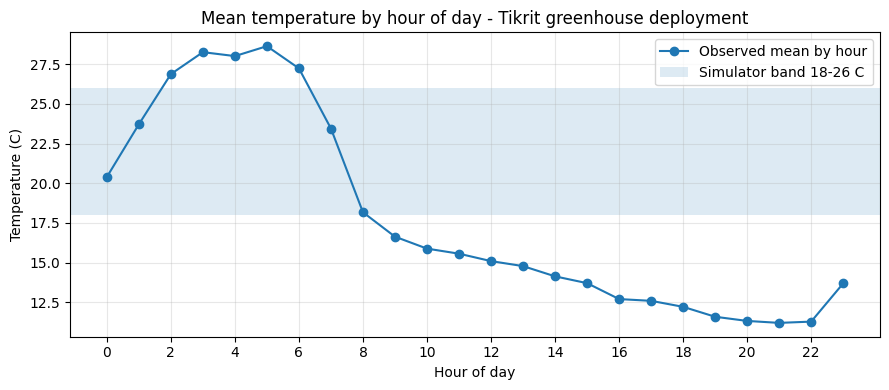

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly.values, marker="o", label="Observed mean by hour")
ax.axhspan(*SIM_BAND, alpha=0.15, label=f"Simulator band {SIM_BAND[0]:.0f}-{SIM_BAND[1]:.0f} C")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Temperature (C)")
ax.set_title("Mean temperature by hour of day - Tikrit greenhouse deployment")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observe the phase before interpreting this.** The profile peaks in the early morning and
troughs in the evening, which is inverted relative to solar forcing. The dataset carries fan and
irrigation actuator states and covers a winter period, so the curve is plausibly dominated by
heating-cycle control rather than by insolation; a logging timezone offset cannot be excluded.

*This matters for the report: do not describe this curve as a natural diurnal cycle.*

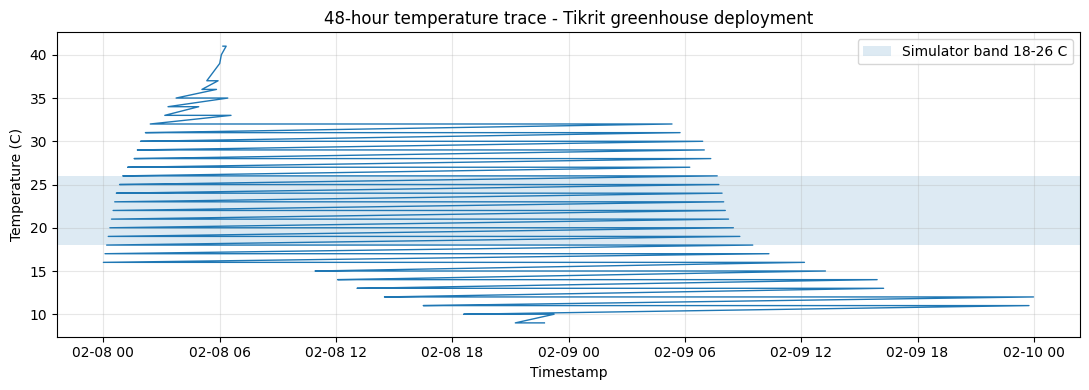

In [7]:
# A 48-hour window, to see what an individual stretch of the deployment actually looks like.
window = tikrit[(tikrit["date"] >= "2024-02-08") & (tikrit["date"] < "2024-02-10")]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(window["date"], window["tempreature"], linewidth=1)
ax.axhspan(*SIM_BAND, alpha=0.15, label=f"Simulator band {SIM_BAND[0]:.0f}-{SIM_BAND[1]:.0f} C")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (C)")
ax.set_title("48-hour temperature trace - Tikrit greenhouse deployment")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Time spent inside the simulator's declared operating band

In [8]:
in_band = temp.between(*SIM_BAND).mean() * 100
print(f"Readings within {SIM_BAND[0]:.0f}-{SIM_BAND[1]:.0f} C: {in_band:.1f}%")
print(f"Readings below {SIM_BAND[0]:.0f} C:        {(temp < SIM_BAND[0]).mean()*100:.1f}%")
print(f"Readings above {SIM_BAND[1]:.0f} C:        {(temp > SIM_BAND[1]).mean()*100:.1f}%")

Readings within 18-26 C: 24.9%
Readings below 18 C:        53.8%
Readings above 26 C:        21.2%


### 1.4 Calibration summary

In [9]:
calibration = pd.DataFrame([
    {"Parameter": "Mean / base temperature",
     "Simulator": f"{SIM_BASE_TEMPS[0]:.1f}-{SIM_BASE_TEMPS[1]:.1f} C",
     "Observed":  f"{temp.mean():.2f} C"},
    {"Parameter": "Diurnal amplitude",
     "Simulator": f"{SIM_AMPLITUDE_C:.1f} C",
     "Observed":  f"{observed_amplitude:.2f} C"},
    {"Parameter": "Full observed range",
     "Simulator": "engineered anomaly windows",
     "Observed":  f"{temp.min():.0f}-{temp.max():.0f} C"},
    {"Parameter": "Time in 18-26 C band",
     "Simulator": "by construction",
     "Observed":  f"{in_band:.1f}%"},
    {"Parameter": "Sampling interval",
     "Simulator": "1 s poll cycle",
     "Observed":  "5 minutes"},
])
calibration

,Parameter,Simulator,Observed
0,Mean / base temperature,20.0-22.0 C,18.76 C
1,Diurnal amplitude,3.5 C,8.72 C
2,Full observed range,engineered anomaly windows,3-41 C
3,Time in 18-26 C band,by construction,24.9%
4,Sampling interval,1 s poll cycle,5 minutes


> **Your interpretation — write this yourself.**
>
> Address, in your own words: which parameter is corroborated; which diverges and by how much;
> whether the divergence is a defect or a modelling decision (a climate-controlled facility versus
> a passively heated agricultural greenhouse); and what the wide observed range implies for the
> realism of the engineered anomaly windows.

---
# Part 2 — Threat-model grounding

Source: ToN_IoT IoT weather telemetry (Alsaedi *et al.*, 2020; and the seven further papers
nominated by UNSW Canberra as a condition of use).

**How the labels were produced.** UNSW labelled records by tagging attacker IP addresses
(192.168.159.30-39) and the timestamps of their activity. Kali Linux hosts were used to attack
cloud gateways, MQTT brokers, Node-RED applications and network services. A record labelled
`1` therefore means *this reading was taken while the deployment was under attack* - it does
**not** mean the reading itself was tampered with. Keep that distinction in the report.

The question this section answers: during documented attack periods, is there a signal in the
telemetry *values* that a value-based filter could act on?

In [10]:
ton = pd.read_csv(DATA_DIR / "Train_Test_IoT_Weather.csv", encoding="utf-8-sig")

print("Records:", len(ton))
print("\nLabel distribution (0 = normal, 1 = attack period):")
print(ton["label"].value_counts().to_string())
print("\nAttack classes:")
print(ton["type"].value_counts().to_string())
ton.head()

Records: 39260

Label distribution (0 = normal, 1 = attack period):
label
1    24260
0    15000

Attack classes:
type
normal        15000
ddos           5000
backdoor       5000
injection      5000
password       5000
ransomware     2865
xss             866
scanning        529


,date,time,temperature,pressure,humidity,label,type
0,25-Apr-19,17:33:16,40.881866,-0.101806,38.363631,1,ddos
1,25-Apr-19,17:33:16,44.913806,2.661616,46.141423,1,ddos
2,25-Apr-19,17:33:16,38.295822,-2.438871,50.850643,1,ddos
3,25-Apr-19,17:33:21,41.306586,-0.101806,38.363631,1,ddos
4,25-Apr-19,17:33:21,44.903178,3.080849,46.141423,1,ddos


### 2.1 Do telemetry values differ between normal and attack periods?

In [11]:
normal    = ton.loc[ton["label"] == 0, "temperature"]
attack    = ton.loc[ton["label"] == 1, "temperature"]
injection = ton.loc[ton["type"] == "injection", "temperature"]   # closest analogue to a rogue tag

summary = pd.DataFrame({
    "n":    [len(normal), len(attack), len(injection)],
    "mean": [normal.mean(), attack.mean(), injection.mean()],
    "sd":   [normal.std(), attack.std(), injection.std()],
    "min":  [normal.min(), attack.min(), injection.min()],
    "max":  [normal.max(), attack.max(), injection.max()],
}, index=["normal", "all attack periods", "injection only"]).round(2)
summary

,n,mean,sd,min,max
normal,15000,35.11,8.73,20.53,49.98
all attack periods,24260,35.33,7.48,20.54,49.45
injection only,5000,36.31,7.67,20.59,49.45


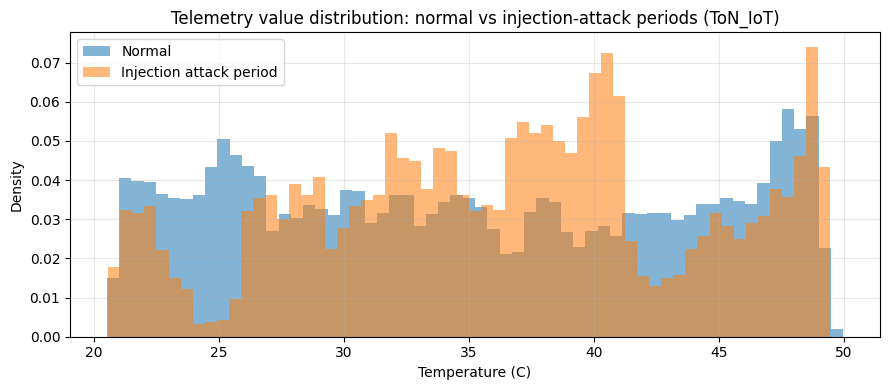

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = 60
ax.hist(normal,    bins=bins, alpha=0.55, density=True, label="Normal")
ax.hist(injection, bins=bins, alpha=0.55, density=True, label="Injection attack period")
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Density")
ax.set_title("Telemetry value distribution: normal vs injection-attack periods (ToN_IoT)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

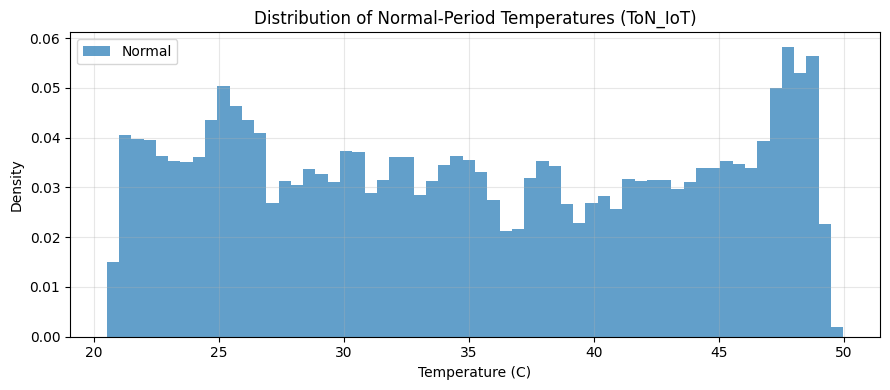

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
bins = 60
ax.hist(normal, bins=bins, alpha=0.7, density=True, label="Normal")
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Normal-Period Temperatures (ToN_IoT)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Is any difference large enough to filter on?

With tens of thousands of records, even a trivial difference in means reaches statistical
significance. Significance alone is therefore the wrong test for the question being asked. What
matters operationally is the **effect size** - whether the two populations are separated enough
that a threshold could tell them apart.

*(If you would rather not defend a t-test and Cohen's d in the viva, delete this cell and argue
from the overlapping ranges in the table above and the histogram alone. That argument is
sufficient on its own.)*

In [14]:
from scipy import stats

def compare(a, b, label):
    t, p = stats.ttest_ind(a, b, equal_var=False)
    pooled_sd = (((a.std() ** 2) + (b.std() ** 2)) / 2) ** 0.5
    d = (b.mean() - a.mean()) / pooled_sd
    print(f"{label}\n  Welch t = {t:.3f}, p = {p:.4g}\n  Cohen's d = {d:.4f}  "
          f"(0.2 = small, 0.5 = medium, 0.8 = large)\n")

compare(normal, attack,    "Normal vs all attack periods")
compare(normal, injection, "Normal vs injection periods")

overlap_lo = max(normal.min(), injection.min())
overlap_hi = min(normal.max(), injection.max())
print(f"Ranges overlap across {overlap_lo:.2f} - {overlap_hi:.2f} C "
      f"(normal spans {normal.min():.2f}-{normal.max():.2f}, "
      f"injection spans {injection.min():.2f}-{injection.max():.2f})")

Normal vs all attack periods
  Welch t = -2.572, p = 0.01011
  Cohen's d = 0.0272  (0.2 = small, 0.5 = medium, 0.8 = large)

Normal vs injection periods
  Welch t = -9.303, p = 1.67e-20
  Cohen's d = 0.1469  (0.2 = small, 0.5 = medium, 0.8 = large)

Ranges overlap across 20.59 - 49.45 C (normal spans 20.53-49.98, injection spans 20.59-49.45)


> **Your interpretation — write this yourself.**
>
> Address, in your own words: what the effect sizes and the overlapping ranges imply about the
> viability of value-based anomaly filtering at the ingestion layer; why this supports
> identity-based rejection at the edge gateway instead; and the limit of what this dataset can
> show, given that the labels mark *attack periods* rather than tampered values.
>
> Then connect it to the artefact's own evaluation: the rogue packets in `test_auth_bridge.py`
> were constructed to be rejected, so they cannot independently establish that rejection is
> necessary. This dataset supplies the external grounding that the artefact's own tests cannot.

---
# Part 3 — Export figures cited in the report

Writes every number quoted in the dissertation to a JSON file, so each claim in the text is
traceable to a reproducible computation.

In [15]:
import json

evidence = {
    "tikrit_calibration": {
        "source": "Abdullah, W.D. and Lifta, M.I. (2024) IoT Agriculture 2024 [Dataset]. Kaggle.",
        "records": int(len(tikrit)),
        "date_span": [str(tikrit["date"].min()), str(tikrit["date"].max())],
        "sampling_interval": str(tikrit["date"].diff().mode()[0]),
        "mean_temperature_c": round(float(temp.mean()), 2),
        "sd_temperature_c": round(float(temp.std()), 2),
        "min_temperature_c": float(temp.min()),
        "max_temperature_c": float(temp.max()),
        "mean_daily_swing_c": round(float(daily["swing"].mean()), 2),
        "sine_equivalent_amplitude_c": round(float(observed_amplitude), 2),
        "peak_hour": int(hourly.idxmax()),
        "trough_hour": int(hourly.idxmin()),
        "pct_within_simulator_band": round(float(in_band), 1),
        "simulator_base_temps_c": list(SIM_BASE_TEMPS),
        "simulator_amplitude_c": SIM_AMPLITUDE_C,
    },
    "ton_iot_threat_model": {
        "source": "Alsaedi et al. (2020) TON_IoT telemetry dataset. UNSW Canberra.",
        "records": int(len(ton)),
        "label_counts": {str(k): int(v) for k, v in ton["label"].value_counts().items()},
        "attack_class_counts": {str(k): int(v) for k, v in ton["type"].value_counts().items()},
        "normal_mean_c": round(float(normal.mean()), 2),
        "attack_mean_c": round(float(attack.mean()), 2),
        "injection_mean_c": round(float(injection.mean()), 2),
        "normal_range_c": [round(float(normal.min()), 2), round(float(normal.max()), 2)],
        "injection_range_c": [round(float(injection.min()), 2), round(float(injection.max()), 2)],
    },
}

out = Path("dataset_calibration_evidence.json")
out.write_text(json.dumps(evidence, indent=2))
print(f"Written to {out.resolve()}")
print(json.dumps(evidence, indent=2)[:900], "...")

Written to /content/dataset_calibration_evidence.json
{
  "tikrit_calibration": {
    "source": "Abdullah, W.D. and Lifta, M.I. (2024) IoT Agriculture 2024 [Dataset]. Kaggle.",
    "records": 37922,
    "date_span": [
      "2023-11-27 06:26:00",
      "2024-03-30 05:24:00"
    ],
    "sampling_interval": "0 days 00:05:00",
    "mean_temperature_c": 18.76,
    "sd_temperature_c": 7.14,
    "min_temperature_c": 3.0,
    "max_temperature_c": 41.0,
    "mean_daily_swing_c": 18.47,
    "sine_equivalent_amplitude_c": 8.72,
    "peak_hour": 5,
    "trough_hour": 21,
    "pct_within_simulator_band": 24.9,
    "simulator_base_temps_c": [
      20.0,
      22.0
    ],
    "simulator_amplitude_c": 3.5
  },
  "ton_iot_threat_model": {
    "source": "Alsaedi et al. (2020) TON_IoT telemetry dataset. UNSW Canberra.",
    "records": 39260,
    "label_counts": {
      "1": 24260,
      "0": 15000
    },
    "attack_class_counts": {
      "normal": 15000,
  ...


---
## Reproduction

```bash
pip install -r requirements.txt
jupyter nbconvert --execute --to notebook --inplace analysis/dataset_calibration.ipynb
```

Restart the kernel and run all cells before committing, so the saved execution counts are
sequential and the stored outputs match the committed code.